In [4]:
#Importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#load dataset
df = pd.read_csv("Housing.csv")


In [6]:
df.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
df.shape


(545, 13)

In [8]:
df.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [11]:
df.duplicated().sum()



np.int64(0)

In [12]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [13]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df = pd.get_dummies(df,drop_first=True)

In [15]:
X = df.drop('price',axis=1)

In [16]:
y = df['price']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [18]:
#Model1: Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred_lr = lr.predict(X_test)

In [20]:
#MAE
from sklearn.metrics import mean_absolute_error

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

In [21]:
#RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

In [22]:
#R**2 Score
from sklearn.metrics import r2_score

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

In [23]:
#Model2: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred_rf = rf.predict(X_test)

In [25]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

In [26]:
comparison = pd.DataFrame({
    'Model':['Linear Regression',
             'Random Forest'],
    'MAE':[mae_lr,
           mae_rf],
    'RMSE':[rmse_lr,
            rmse_rf],
    'R2 Score':[r2_lr,
                r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [27]:
import os

os.makedirs(
    "charts",
    exist_ok=True
)

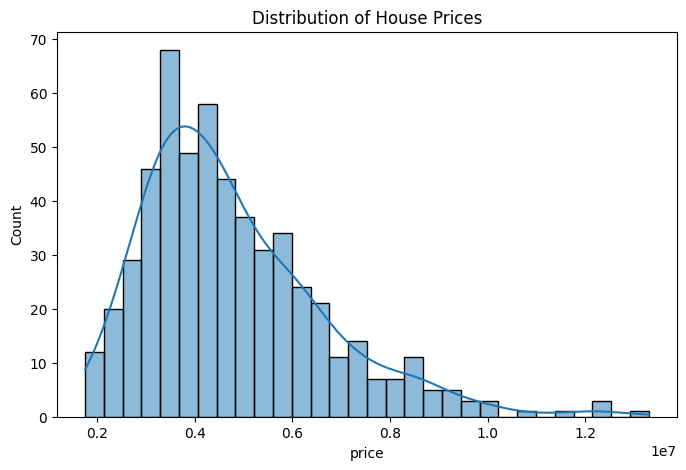

In [28]:
#Histplot
plt.figure(figsize=(8,5))

sns.histplot(
    df['price'],
    bins=30,
    kde=True
)

plt.title(
    'Distribution of House Prices'
)

plt.savefig(
    'charts/price_distribution.png'
)

plt.show()

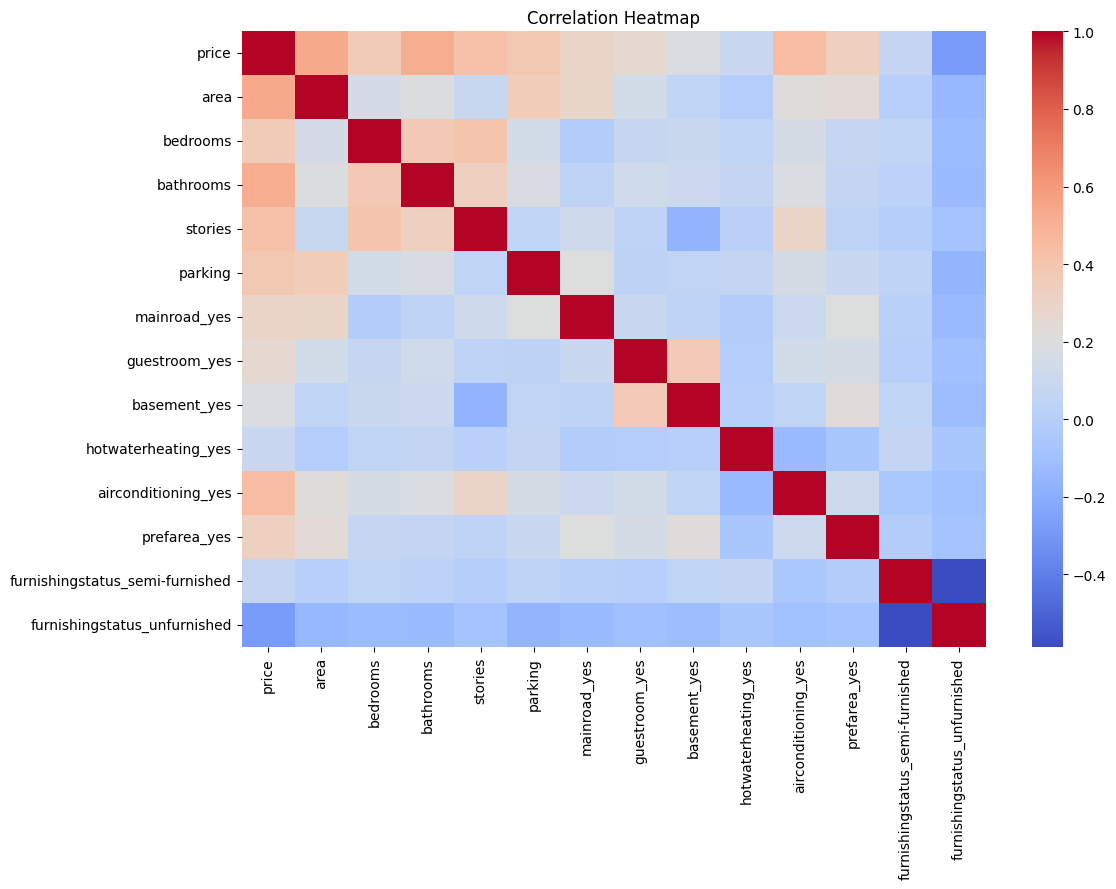

In [29]:
#Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.savefig(
    'charts/correlation_heatmap.png'
)

plt.show()

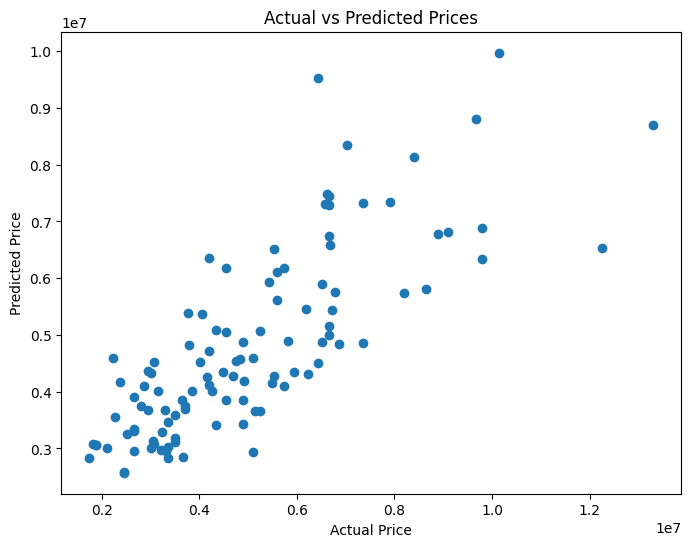

In [30]:
#scatter plot

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel(
    'Actual Price'
)

plt.ylabel(
    'Predicted Price'
)

plt.title(
    'Actual vs Predicted Prices'
)

plt.savefig(
    'charts/actual_vs_predicted.png'
)

plt.show()

In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


In [32]:
import os
os.getcwd()

'C:\\Users\\Rakshita\\HousePricePrediction_RakshitaDeshpande'

In [33]:
import os
os.makedirs("charts", exist_ok=True)

In [34]:
os.listdir()

['.ipynb_checkpoints',
 'analysis.ipynb',
 'charts',
 'House Price Prediction-Summary.docx',
 'Housing.csv']

In [35]:
os.listdir('charts')

['actual_vs_predicted.png',
 'correlation_heatmap.png',
 'price_distribution.png']